<a href="https://colab.research.google.com/github/sadhika-tech/deep-learning-lab/blob/main/Lab%206/rnn_lstm_gru.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!wget https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip -O /content/har.zip

--2026-09-23 09:21:53--  https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘/content/har.zip’

/content/har.zip        [    <=>             ]  58.18M  73.6MB/s    in 0.8s    

2026-09-23 09:21:54 (73.6 MB/s) - ‘/content/har.zip’ saved [61005872]



In [3]:
!unzip -q /content/har.zip -d /content/

In [4]:
!ls "/content"

 drive	 har.zip   sample_data	'UCI HAR Dataset.names'  'UCI HAR Dataset.zip'


In [5]:
!unzip -q "/content/UCI HAR Dataset.zip" -d "/content/"

In [6]:
!ls "/content/UCI HAR Dataset"

activity_labels.txt  features_info.txt	features.txt  README.txt  test	train


In [7]:
!ls "/content/UCI HAR Dataset/train/Inertial Signals/body_acc_x_train.txt"

'/content/UCI HAR Dataset/train/Inertial Signals/body_acc_x_train.txt'


In [8]:
import os, time, zipfile, io, requests, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, Input
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

In [9]:
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

ACTIVITIES = ["WALKING", "WALKING_UPSTAIRS", "WALKING_DOWNSTAIRS",
              "SITTING", "STANDING", "LAYING"]

In [10]:
DATA_DIR = "/content/UCI HAR Dataset"

SIGNALS = [
    "body_acc_x", "body_acc_y", "body_acc_z",
    "body_gyro_x", "body_gyro_y", "body_gyro_z",
    "total_acc_x", "total_acc_y", "total_acc_z",
]

def load_signals(split):
    base = os.path.join(DATA_DIR, split, "Inertial Signals")
    data = []
    for sig in SIGNALS:
        path = os.path.join(base, f"{sig}_{split}.txt")
        arr = np.loadtxt(path)
        data.append(arr)
    # (channels, N, 128) -> (N, 128, channels)
    return np.transpose(np.array(data), (1, 2, 0))

def load_labels(split):
    path = os.path.join(DATA_DIR, split, f"y_{split}.txt")
    return np.loadtxt(path).astype(int) - 1  # 0-indexed, 6 classes

X_train_full = load_signals("train")
y_train_full = load_labels("train")
X_test_full = load_signals("test")
y_test_full = load_labels("test")

In [11]:
print("Full train:", X_train_full.shape, "Full test:", X_test_full.shape)

Full train: (7352, 128, 9) Full test: (2947, 128, 9)


In [12]:
N_SUBSET = 2400

rng = np.random.default_rng(SEED)
idx_by_class = {c: np.where(y_train_full == c)[0] for c in range(6)}
per_class = N_SUBSET // 6
subset_idx = np.concatenate([
    rng.choice(idx_by_class[c], size=min(per_class, len(idx_by_class[c])), replace=False)
    for c in range(6)
])
rng.shuffle(subset_idx)

X_sub, y_sub = X_train_full[subset_idx], y_train_full[subset_idx]
print("Subset shape:", X_sub.shape, "Class counts:", np.bincount(y_sub))

Subset shape: (2400, 128, 9) Class counts: [400 400 400 400 400 400]


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X_sub, y_sub, test_size=0.30, stratify=y_sub, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED)

# Normalize using TRAIN statistics only
mean = X_train.mean(axis=(0, 1), keepdims=True)
std = X_train.std(axis=(0, 1), keepdims=True) + 1e-8
X_train_n = (X_train - mean) / std
X_val_n = (X_val - mean) / std
X_test_n = (X_test - mean) / std

print("Input tensor shape:")
print(f"  Training   : {X_train_n.shape}")
print(f"  Validation : {X_val_n.shape}")
print(f"  Testing    : {X_test_n.shape}")
print(f"Number of classes: 6")
print(f"Number of features per time step: {X_train_n.shape[2]}")
print(f"Sequence length: {X_train_n.shape[1]}")

print("\nClass distribution (train):", np.bincount(y_train))
print("Class distribution (val)  :", np.bincount(y_val))
print("Class distribution (test) :", np.bincount(y_test))

Input tensor shape:
  Training   : (1680, 128, 9)
  Validation : (360, 128, 9)
  Testing    : (360, 128, 9)
Number of classes: 6
Number of features per time step: 9
Sequence length: 128

Class distribution (train): [280 280 280 280 280 280]
Class distribution (val)  : [60 60 60 60 60 60]
Class distribution (test) : [60 60 60 60 60 60]


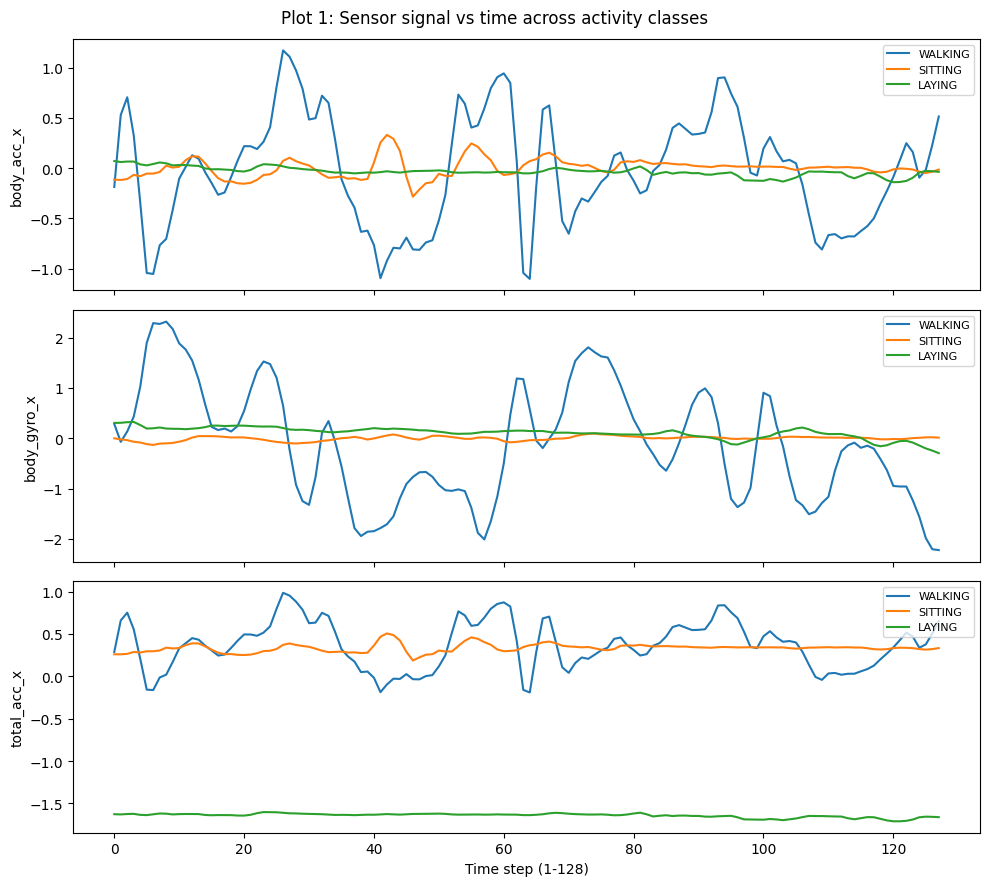

In [14]:
fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
chan_names = ["body_acc_x", "body_gyro_x", "total_acc_x"]
chan_idx = [SIGNALS.index(c) for c in chan_names]
example_classes = [0, 3, 5]  # WALKING, SITTING, LAYING

for ax, ch, ch_name in zip(axes, chan_idx, chan_names):
    for c in example_classes:
        sample_idx = np.where(y_train == c)[0][0]
        ax.plot(X_train_n[sample_idx, :, ch], label=ACTIVITIES[c])
    ax.set_ylabel(ch_name)
    ax.legend(loc="upper right", fontsize=8)
axes[-1].set_xlabel("Time step (1-128)")
fig.suptitle("Plot 1: Sensor signal vs time across activity classes")
plt.tight_layout()
plt.show()


In [15]:
def manual_rnn_step(x, h_prev, Wx=0.5, Wh=0.8, b=0.1):
    return np.tanh(Wx * x + Wh * h_prev + b)

x_vals = [0.5, 0.7, 0.2]
h = 0.0
h_history = []
for t, x in enumerate(x_vals, start=1):
    h = manual_rnn_step(x, h)
    h_history.append(h)
    print(f"h{t} = {h:.6f}")

print("\nCompare with a 1-unit SimpleRNN cell:")
cell = layers.SimpleRNNCell(1, activation='tanh',
                             kernel_initializer=tf.constant_initializer(0.5),
                             recurrent_initializer=tf.constant_initializer(0.8),
                             bias_initializer=tf.constant_initializer(0.1))
state = [tf.zeros((1, 1))]
for t, x in enumerate(x_vals, start=1):
    out, state = cell(tf.constant([[x]], dtype=tf.float32), state)
    print(f"h{t} (Keras) = {out.numpy()[0,0]:.6f}")

h1 = 0.336376
h2 = 0.616352
h3 = 0.599958

Compare with a 1-unit SimpleRNN cell:
h1 (Keras) = 0.336376
h2 (Keras) = 0.616352
h3 (Keras) = 0.599958


In [16]:
def build_model(rnn_type, seq_len=128, n_features=9, units=32, n_classes=6):
    RecurrentLayer = {"RNN": layers.SimpleRNN, "LSTM": layers.LSTM, "GRU": layers.GRU}[rnn_type]
    model = models.Sequential([
        Input(shape=(seq_len, n_features)),
        RecurrentLayer(units),
        layers.Dropout(0.2),
        layers.Dense(16, activation="relu"),
        layers.Dense(n_classes, activation="softmax"),
    ], name=f"{rnn_type}_classifier")
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

def train_and_time(model, X_tr, y_tr, X_v, y_v, epochs=30, batch_size=32, verbose=0):
    start = time.time()
    history = model.fit(X_tr, y_tr, validation_data=(X_v, y_v),
                         epochs=epochs, batch_size=batch_size, verbose=verbose)
    elapsed = time.time() - start
    return history, elapsed

for rt in ["RNN", "LSTM", "GRU"]:
    build_model(rt).summary()

Model: "RNN_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,974 (7.71 KB)

 Trainable params: 1,974 (7.71 KB)

 Non-trainable params: 0 (0.00 B)

...

Model: "GRU_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,758 (18.59 KB)

 Trainable params: 4,758 (18.59 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
EPOCHS = 30
results = {}
histories = {}

for rnn_type in ["RNN", "LSTM", "GRU"]:
    print(f"\n=== Training {rnn_type} ===")
    model = build_model(rnn_type)
    history, train_time = train_and_time(model, X_train_n, y_train, X_val_n, y_val,
                                          epochs=EPOCHS, verbose=1)
    histories[rnn_type] = history
    results[rnn_type] = {"model": model, "train_time": train_time,
                          "params": model.count_params()}
    print(f"{rnn_type} trained in {train_time:.2f}s, params={model.count_params()}")


=== Training RNN ===
Epoch 1/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 8s 78ms/step - accuracy: 0.3702 - loss: 1.6489 - val_accuracy: 0.5139 - val_loss: 1.3299
Epoch 2/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5137 - loss: 1.2957 - val_accuracy: 0.5611 - val_loss: 1.1403
Epoch 3/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5750 - loss: 1.1385 - val_accuracy: 0.5889 - val_loss: 1.0321
Epoch 4/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6196 - loss: 1.0064 - val_accuracy: 0.6306 - val_loss: 0.9353
Epoch 5/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6369 - loss: 0.9460 - val_accuracy: 0.6806 - val_loss: 0.8674
Epoch 6/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6673 - loss: 0.8640 - val_accuracy: 0.6750 - val_loss: 0.8424
Epoch 7/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6208 - loss: 0.9153 - val_accuracy: 0.7056 - val_loss: 0.7885
Epoch 8/30
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6696 - loss: 0.7705 - va

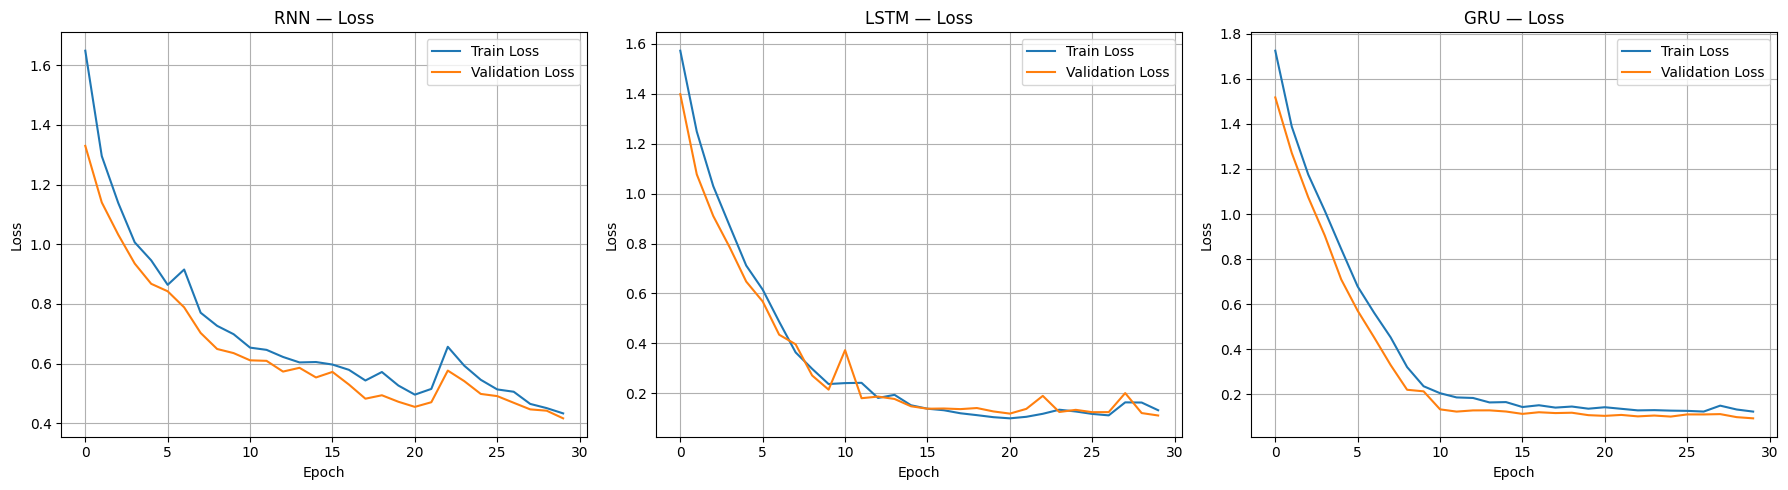

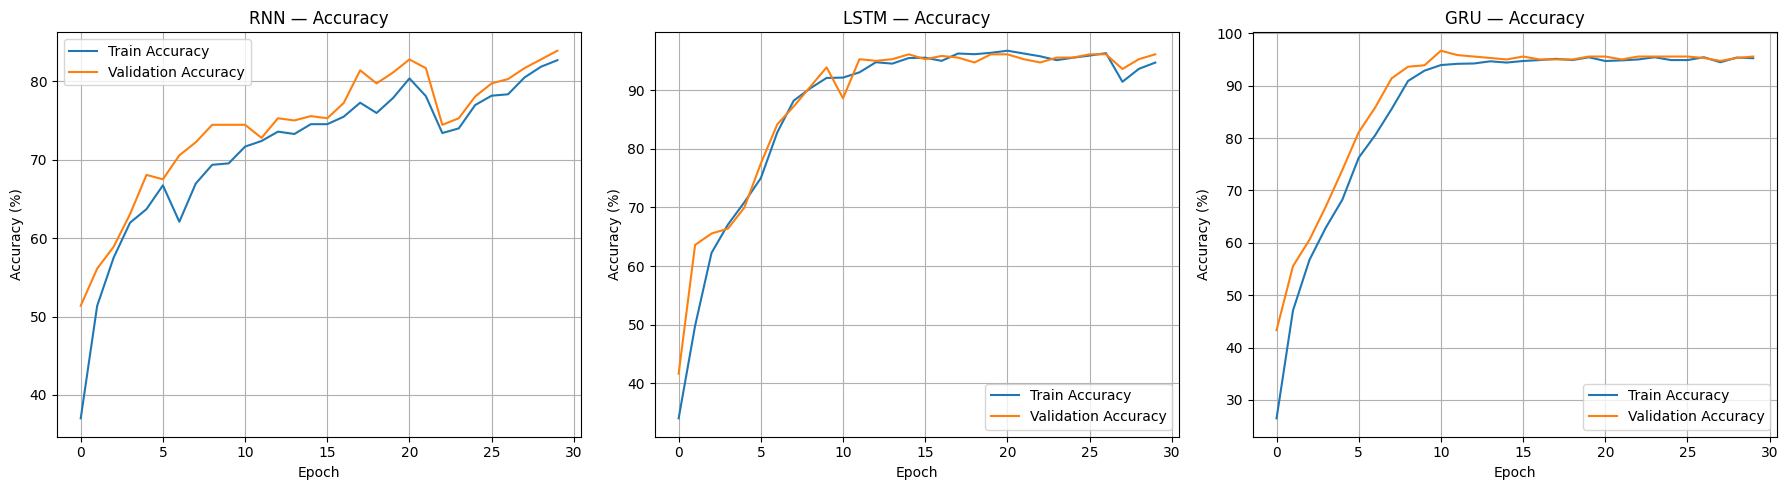

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, rnn_type in enumerate(["RNN", "LSTM", "GRU"]):

    h = histories[rnn_type].history

    axes[i].plot(h["loss"], label="Train Loss")
    axes[i].plot(h["val_loss"], label="Validation Loss")

    axes[i].set_title(f"{rnn_type} — Loss")
    axes[i].set_xlabel("Epoch")
    axes[i].set_ylabel("Loss")
    axes[i].legend()
    axes[i].grid(True)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, rnn_type in enumerate(["RNN", "LSTM", "GRU"]):

    h = histories[rnn_type].history

    axes[i].plot(np.array(h["accuracy"]) * 100, label="Train Accuracy")
    axes[i].plot(np.array(h["val_accuracy"]) * 100, label="Validation Accuracy")

    axes[i].set_title(f"{rnn_type} — Accuracy")
    axes[i].set_xlabel("Epoch")
    axes[i].set_ylabel("Accuracy (%)")
    axes[i].legend()
    axes[i].grid(True)

plt.tight_layout()
plt.show()

In [22]:
def evaluate_model(model, X_te, y_te, name):
    y_prob = model.predict(X_te, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)
    acc = accuracy_score(y_te, y_pred) * 100
    prec = precision_score(y_te, y_pred, average="macro", zero_division=0) * 100
    rec = recall_score(y_te, y_pred, average="macro", zero_division=0) * 100
    f1 = f1_score(y_te, y_pred, average="macro", zero_division=0) * 100
    cm = confusion_matrix(y_te, y_pred)
    return {"name": name, "accuracy": acc, "precision": prec, "recall": rec,
            "f1": f1, "confusion_matrix": cm, "y_pred": y_pred}

eval_results = {}
for rnn_type in ["RNN", "LSTM", "GRU"]:
    eval_results[rnn_type] = evaluate_model(results[rnn_type]["model"], X_test_n, y_test, rnn_type)
    r = eval_results[rnn_type]
    print(f"{rnn_type}: Acc={r['accuracy']:.2f}%  Prec={r['precision']:.2f}%  "
          f"Rec={r['recall']:.2f}%  F1={r['f1']:.2f}%")

RNN: Acc=82.50%  Prec=82.31%  Rec=82.50%  F1=82.25%
LSTM: Acc=93.06%  Prec=93.18%  Rec=93.06%  F1=92.96%
GRU: Acc=93.06%  Prec=93.03%  Rec=93.06%  F1=93.00%


In [39]:
metric_table = pd.DataFrame({
    rnn_type: [
        round(eval_results[rnn_type]["accuracy"], 2),
        round(eval_results[rnn_type]["precision"], 2),
        round(eval_results[rnn_type]["recall"], 2),
        round(eval_results[rnn_type]["f1"], 2),
        results[rnn_type]["params"],
        round(results[rnn_type]["train_time"], 2),
    ]
    for rnn_type in ["RNN", "LSTM", "GRU"]
}, index=["Accuracy (%)", "Macro Precision (%)", "Macro Recall (%)",
          "Macro F1 (%)", "Parameters", "Training Time (s)"])

print("Table (Section 14): RNN vs LSTM vs GRU")
display(metric_table)

Table (Section 14): RNN vs LSTM vs GRU


,RNN,LSTM,GRU
Accuracy (%),82.50,93.06,93.06
Macro Precision (%),82.31,93.18,93.03
Macro Recall (%),82.50,93.06,93.06
Macro F1 (%),82.25,92.96,93.00
Parameters,1974.00,6006.00,4758.00
Training Time (s),28.64,26.94,20.27


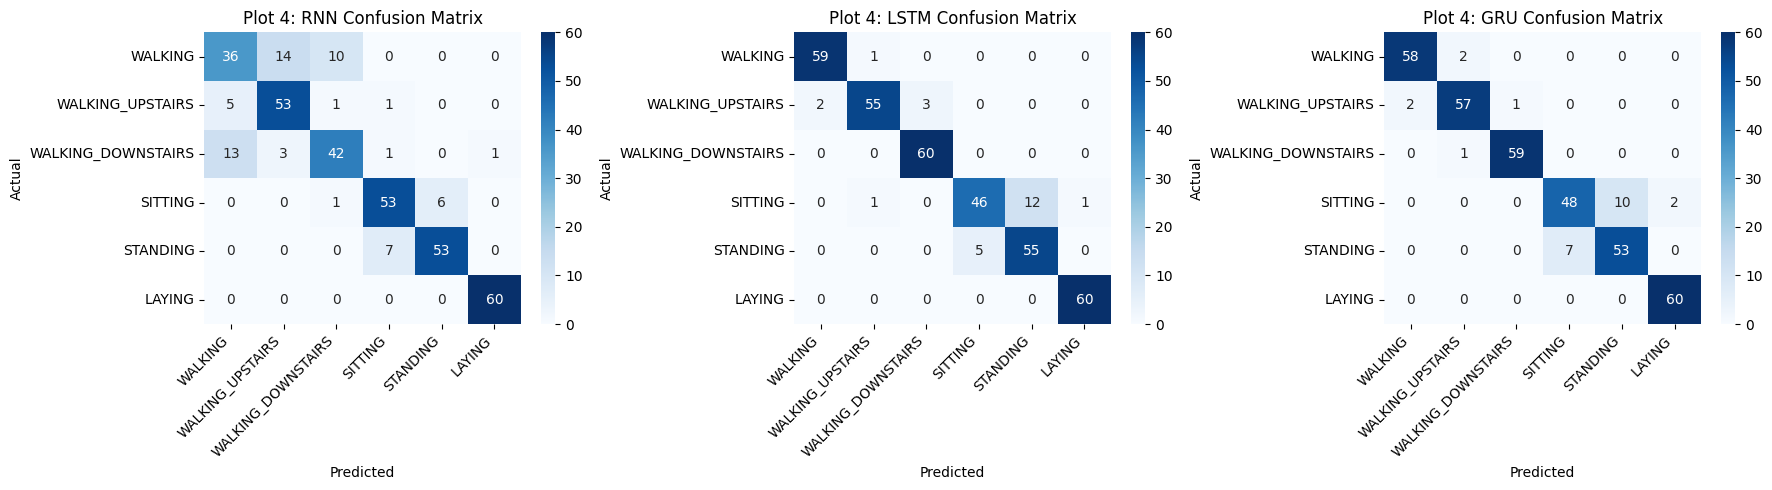

RNN: highest recognition = LAYING; most-confused pair = WALKING -> WALKING_UPSTAIRS (14 instances)
LSTM: highest recognition = WALKING_DOWNSTAIRS; most-confused pair = SITTING -> STANDING (12 instances)
GRU: highest recognition = LAYING; most-confused pair = SITTING -> STANDING (10 instances)


In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, rnn_type in zip(axes, ["RNN", "LSTM", "GRU"]):
    cm = eval_results[rnn_type]["confusion_matrix"]
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=ACTIVITIES, yticklabels=ACTIVITIES)
    ax.set_title(f"Plot 4: {rnn_type} Confusion Matrix")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()

for rnn_type in ["RNN", "LSTM", "GRU"]:
    cm = eval_results[rnn_type]["confusion_matrix"]
    best = ACTIVITIES[np.argmax(np.diag(cm))]
    off_diag = cm.copy(); np.fill_diagonal(off_diag, 0)
    worst_pair_idx = np.unravel_index(np.argmax(off_diag), off_diag.shape)
    print(f"{rnn_type}: highest recognition = {best}; most-confused pair = "
          f"{ACTIVITIES[worst_pair_idx[0]]} -> {ACTIVITIES[worst_pair_idx[1]]} "
          f"({off_diag[worst_pair_idx]} instances)")

In [24]:
gate_info = {
    "RNN":  dict(hidden="Yes", cell="No",  forget="No",  input="No",  output="No",  update="No",  reset="No"),
    "LSTM": dict(hidden="Yes", cell="Yes", forget="Yes", input="Yes", output="Yes", update="No",  reset="No"),
    "GRU":  dict(hidden="Yes", cell="No",  forget="No",  input="No",  output="No",  update="Yes", reset="Yes"),
}

comparison_rows = []
for rnn_type in ["RNN", "LSTM", "GRU"]:
    g = gate_info[rnn_type]
    r = eval_results[rnn_type]
    comparison_rows.append({
        "Property": rnn_type, **g,
        "Parameters": results[rnn_type]["params"],
        "Training time (s)": round(results[rnn_type]["train_time"], 2),
        "Test F1-score (%)": round(r["f1"], 2),
    })

comparison_df = pd.DataFrame(comparison_rows).set_index("Property")
comparison_df

,hidden,cell,forget,input,output,update,reset,Parameters,Training time (s),Test F1-score (%)
Property,,,,,,,,,,
RNN,Yes,No,No,No,No,No,No,1974,28.64,82.25
LSTM,Yes,Yes,Yes,Yes,Yes,No,No,6006,26.94,92.96
GRU,Yes,No,No,No,No,Yes,Yes,4758,20.27,93.00


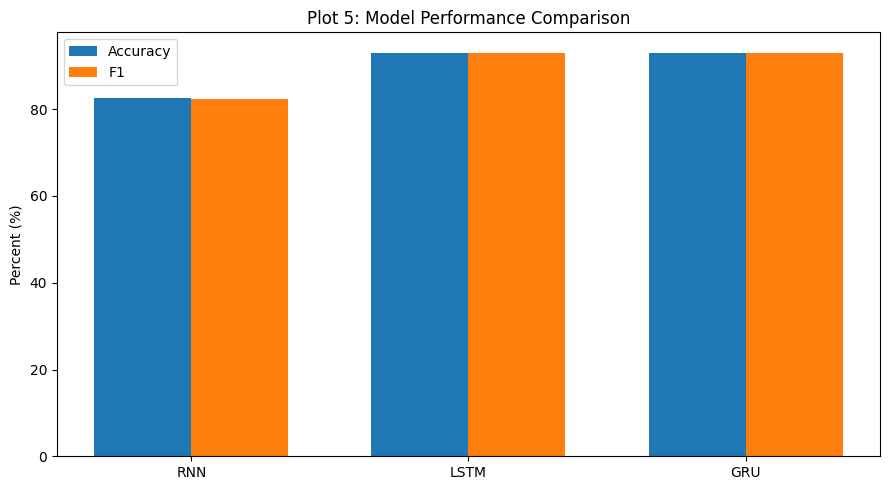

In [25]:
fig, ax = plt.subplots(figsize=(9, 5))
metrics_to_plot = ["accuracy", "f1"]
x = np.arange(3)
width = 0.35
for i, m in enumerate(metrics_to_plot):
    vals = [eval_results[rt][m] for rt in ["RNN", "LSTM", "GRU"]]
    ax.bar(x + i * width, vals, width, label=m.capitalize())
ax.set_xticks(x + width / 2)
ax.set_xticklabels(["RNN", "LSTM", "GRU"])
ax.set_ylabel("Percent (%)")
ax.set_title("Plot 5: Model Performance Comparison")
ax.legend()
plt.tight_layout()
plt.show()

In [26]:
def truncate_seq(X, T):
    return X[:, :T, :]

seq_lengths = [32, 64, 128]
seqlen_results = {rt: {} for rt in ["RNN", "LSTM", "GRU"]}

for T in seq_lengths:
    Xtr_T = truncate_seq(X_train_n, T)
    Xv_T = truncate_seq(X_val_n, T)
    Xte_T = truncate_seq(X_test_n, T)
    for rnn_type in ["RNN", "LSTM", "GRU"]:
        model = build_model(rnn_type, seq_len=T)
        model.fit(Xtr_T, y_train, validation_data=(Xv_T, y_val),
                  epochs=15, batch_size=32, verbose=0)
        y_pred = np.argmax(model.predict(Xte_T, verbose=0), axis=1)
        f1 = f1_score(y_test, y_pred, average="macro", zero_division=0) * 100
        seqlen_results[rnn_type][T] = f1
        print(f"T={T:3d}  {rnn_type}: F1={f1:.2f}%")

seqlen_df = pd.DataFrame(seqlen_results)
seqlen_df.index.name = "Sequence Length"
seqlen_df

T= 32  RNN: F1=73.42%
T= 32  LSTM: F1=92.77%
T= 32  GRU: F1=90.52%
T= 64  RNN: F1=74.47%
T= 64  LSTM: F1=91.63%
T= 64  GRU: F1=92.12%
T=128  RNN: F1=73.81%
T=128  LSTM: F1=90.26%
T=128  GRU: F1=93.88%


,RNN,LSTM,GRU
Sequence Length,,,
32,73.416298,92.768350,90.523579
64,74.467127,91.626596,92.117688
128,73.811818,90.260255,93.879652


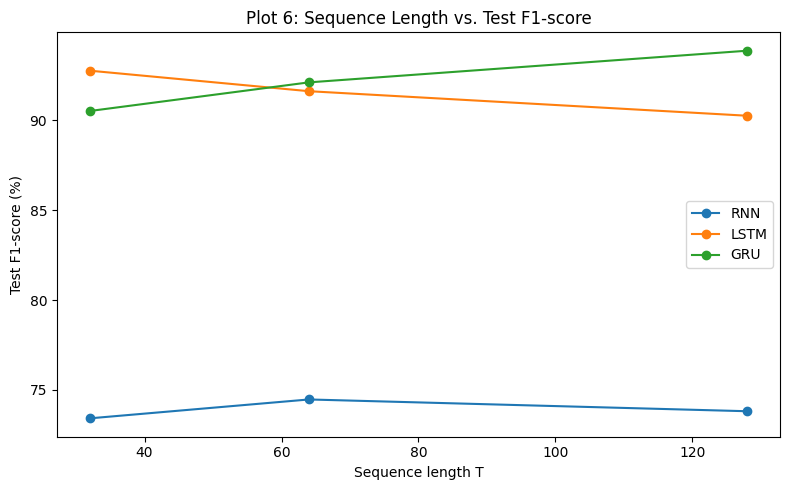

In [27]:
fig, ax = plt.subplots(figsize=(8, 5))
for rnn_type in ["RNN", "LSTM", "GRU"]:
    ax.plot(seq_lengths, [seqlen_results[rnn_type][T] for T in seq_lengths],
            marker="o", label=rnn_type)
ax.set_xlabel("Sequence length T")
ax.set_ylabel("Test F1-score (%)")
ax.set_title("Plot 6: Sequence Length vs. Test F1-score")
ax.legend()
plt.tight_layout()
plt.show()

In [41]:
import tarfile, collections, pathlib

UCF_TOP5_URL = "https://github.com/sayakpaul/Action-Recognition-in-TensorFlow/releases/download/v1.0.0/ucf101_top5.tar.gz"
ARCHIVE_PATH = "ucf101_top5.tar.gz"
RAW_DIR = pathlib.Path("ucf101_top5_raw")

if not RAW_DIR.exists():
    if not os.path.exists(ARCHIVE_PATH):
        print("Downloading UCF101 5-class subset (~450 MB)...")
        urllib.request.urlretrieve(UCF_TOP5_URL, ARCHIVE_PATH)
    print("Extracting...")
    with tarfile.open(ARCHIVE_PATH) as tf_:  # not actually gzip-compressed despite the extension
        tf_.extractall(RAW_DIR)

raw_splits = [p for p in RAW_DIR.iterdir() if p.is_dir()]
print("Extracted folders:", [p.name for p in raw_splits])

Extracting...


/tmp/ipykernel_4573/1819457874.py:13: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tf_.extractall(RAW_DIR)


Extracted folders: ['test', 'train']


In [42]:
def ucf_class_of(filename):
    # filenames look like: v_TennisSwing_g09_c02.avi -> class = TennisSwing
    return filename.split("_")[1]

files_by_class = collections.defaultdict(list)
for split_dir in raw_splits:
    for f in split_dir.glob("*.avi"):
        files_by_class[ucf_class_of(f.name)].append(f)

for c, fl in files_by_class.items():
    print(c, "->", len(fl), "clips")

VIDEO_CLASSES = sorted(files_by_class.keys())  # all 5 classes present in the subset
N_PER_CLASS = 15  # keep small so feature extraction / training stays fast on Colab
VIDEO_ROOT = pathlib.Path("videos")

VIDEO_ROOT.mkdir(exist_ok=True)
for c in VIDEO_CLASSES:
    class_dir = VIDEO_ROOT / c
    class_dir.mkdir(exist_ok=True)
    for src in files_by_class[c][:N_PER_CLASS]:
        dst = class_dir / src.name
        if not dst.exists():
            dst.symlink_to(src.resolve())

print("Videos staged:")
for c in VIDEO_CLASSES:
    print(" ", c, "->", len(list((VIDEO_ROOT / c).glob("*.avi"))), "files")

CricketShot -> 167 clips
TennisSwing -> 166 clips
ShavingBeard -> 161 clips
Punch -> 160 clips
PlayingCello -> 164 clips
Videos staged:
  CricketShot -> 15 files
  PlayingCello -> 15 files
  Punch -> 15 files
  ShavingBeard -> 15 files
  TennisSwing -> 15 files


In [43]:
import cv2
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

N_FRAMES = 10
FRAME_SIZE = (224, 224)

def sample_frames(video_path, n_frames=N_FRAMES, size=FRAME_SIZE):
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total <= 0:
        cap.release()
        return None
    idxs = np.linspace(0, max(total - 1, 0), n_frames).astype(int)
    frames = []
    for i in range(total):
        ret, frame = cap.read()
        if not ret:
            break
        if i in idxs:
            frame = cv2.resize(frame, size)
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame)
    cap.release()
    if len(frames) < n_frames:
        return None
    return np.array(frames[:n_frames])

cnn_extractor = MobileNetV2(include_top=False, weights="imagenet",
                             pooling="avg", input_shape=(224, 224, 3))
cnn_extractor.trainable = False
FEATURE_DIM = cnn_extractor.output_shape[-1]
print("CNN feature dimension D =", FEATURE_DIM)

def extract_video_features(frames):
    x = preprocess_input(frames.astype(np.float32))
    feats = cnn_extractor.predict(x, verbose=0)  # (N_FRAMES, D)
    return feats

video_paths, video_labels = [], []
for ci, c in enumerate(VIDEO_CLASSES):
    folder = VIDEO_ROOT / c
    for fn in os.listdir(folder):
        if fn.lower().endswith((".avi", ".mp4", ".mov")):
            video_paths.append(str(folder / fn))
            video_labels.append(ci)

print(f"Found {len(video_paths)} video files across {len(VIDEO_CLASSES)} classes.")

if len(video_paths) == 0:
    print("No videos found yet — add clips under 'videos/<class>/' and re-run this cell "
          "before continuing to the CNN-LSTM training cells below.")
else:
    X_vid_feats, y_vid = [], []
    for path, label in zip(video_paths, video_labels):
        frames = sample_frames(path)
        if frames is None:
            continue
        X_vid_feats.append(extract_video_features(frames))
        y_vid.append(label)
    X_vid_feats = np.array(X_vid_feats)  # (B, 10, D)
    y_vid = np.array(y_vid)
    print("Video feature tensor shape:", X_vid_feats.shape)

CNN feature dimension D = 1280
Found 75 video files across 5 classes.
Video feature tensor shape: (71, 10, 1280)


In [29]:
N_FRAMES = 10
FRAME_SIZE = (224, 224)

def sample_frames(video_path, n_frames=N_FRAMES, size=FRAME_SIZE):
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total <= 0:
        cap.release()
        return None
    idxs = np.linspace(0, max(total - 1, 0), n_frames).astype(int)
    frames = []
    for i in range(total):
        ret, frame = cap.read()
        if not ret:
            break
        if i in idxs:
            frame = cv2.resize(frame, size)
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame)
    cap.release()
    if len(frames) < n_frames:
        return None
    return np.array(frames[:n_frames])

cnn_extractor = MobileNetV2(include_top=False, weights="imagenet",
                             pooling="avg", input_shape=(224, 224, 3))
cnn_extractor.trainable = False
FEATURE_DIM = cnn_extractor.output_shape[-1]
print("CNN feature dimension D =", FEATURE_DIM)

def extract_video_features(frames):
    x = preprocess_input(frames.astype(np.float32))
    feats = cnn_extractor.predict(x, verbose=0)  # (N_FRAMES, D)
    return feats

video_paths, video_labels = [], []
for ci, c in enumerate(VIDEO_CLASSES):
    folder = os.path.join(VIDEO_ROOT, c)
    for fn in os.listdir(folder):
        if fn.lower().endswith((".mp4", ".avi", ".mov")):
            video_paths.append(os.path.join(folder, fn))
            video_labels.append(ci)

print(f"Found {len(video_paths)} video files across {len(VIDEO_CLASSES)} classes.")

if len(video_paths) == 0:
    print("No videos found yet — add clips under 'videos/<class>/' and re-run this cell "
          "before continuing to the CNN-LSTM training cells below.")
else:
    X_vid_feats, y_vid = [], []
    for path, label in zip(video_paths, video_labels):
        frames = sample_frames(path)
        if frames is None:
            continue
        X_vid_feats.append(extract_video_features(frames))
        y_vid.append(label)
    X_vid_feats = np.array(X_vid_feats)  # (B, 10, D)
    y_vid = np.array(y_vid)
    print("Video feature tensor shape:", X_vid_feats.shape)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
CNN feature dimension D = 1280
Found 0 video files across 3 classes.
No videos found yet — add clips under 'videos/<class>/' and re-run this cell before continuing to the CNN-LSTM training cells below.


In [44]:
if len(video_paths) > 0 and len(X_vid_feats) >= 6:
    Xv_tr, Xv_te, yv_tr, yv_te = train_test_split(
        X_vid_feats, y_vid, test_size=0.25, stratify=y_vid, random_state=SEED)
    Xv_tr, Xv_val, yv_tr, yv_val = train_test_split(
        Xv_tr, yv_tr, test_size=0.2, stratify=yv_tr, random_state=SEED)

    def build_video_model(rnn_type="LSTM", n_classes=len(VIDEO_CLASSES)):
        RecurrentLayer = {"LSTM": layers.LSTM, "GRU": layers.GRU}[rnn_type]
        m = models.Sequential([
            Input(shape=(N_FRAMES, FEATURE_DIM)),
            RecurrentLayer(32),
            layers.Dense(16, activation="relu"),
            layers.Dense(n_classes, activation="softmax"),
        ])
        m.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
        return m

    video_model = build_video_model("LSTM")
    vid_history = video_model.fit(Xv_tr, yv_tr, validation_data=(Xv_val, yv_val),
                                   epochs=20, batch_size=4, verbose=1)

    y_vid_prob = video_model.predict(Xv_te, verbose=0)
    y_vid_pred = np.argmax(y_vid_prob, axis=1)
    for i in range(len(Xv_te)):
        print(f"Predicted class: {VIDEO_CLASSES[y_vid_pred[i]]:15s}  "
              f"Actual class: {VIDEO_CLASSES[yv_te[i]]:15s}  "
              f"Confidence: {y_vid_prob[i, y_vid_pred[i]]:.2f}")
else:
    print("Skipping video model training — not enough labeled video clips yet.")

Epoch 1/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.4524 - loss: 1.4859 - val_accuracy: 0.5455 - val_loss: 1.2429
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7619 - loss: 0.9150 - val_accuracy: 0.6364 - val_loss: 0.9213
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8333 - loss: 0.6235 - val_accuracy: 0.8182 - val_loss: 0.7024
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9762 - loss: 0.4324 - val_accuracy: 0.9091 - val_loss: 0.5509
Epoch 5/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.3309 - val_accuracy: 0.9091 - val_loss: 0.5009
Epoch 6/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.2353 - val_accuracy: 0.8182 - val_loss: 0.4986
Epoch 7/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.1957 - val_accuracy: 0.8182 - val_loss: 0.4759
Epoch 8/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.1502 - val_accuracy: 0.9091 - v

In [45]:
if len(video_paths) > 0 and len(X_vid_feats) >= 6:
    Xv_tr, Xv_te, yv_tr, yv_te = train_test_split(
        X_vid_feats, y_vid, test_size=0.25, stratify=y_vid, random_state=SEED)
    Xv_tr, Xv_val, yv_tr, yv_val = train_test_split(
        Xv_tr, yv_tr, test_size=0.2, stratify=yv_tr, random_state=SEED)

    def build_video_model(rnn_type="LSTM", n_classes=len(VIDEO_CLASSES)):
        RecurrentLayer = {"LSTM": layers.LSTM, "GRU": layers.GRU}[rnn_type]
        m = models.Sequential([
            Input(shape=(N_FRAMES, FEATURE_DIM)),
            RecurrentLayer(32),
            layers.Dense(16, activation="relu"),
            layers.Dense(n_classes, activation="softmax"),
        ])
        m.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
        return m

    video_model = build_video_model("LSTM")
    vid_history = video_model.fit(Xv_tr, yv_tr, validation_data=(Xv_val, yv_val),
                                   epochs=20, batch_size=4, verbose=1)

    y_vid_prob = video_model.predict(Xv_te, verbose=0)
    y_vid_pred = np.argmax(y_vid_prob, axis=1)
    for i in range(len(Xv_te)):
        print(f"Predicted class: {VIDEO_CLASSES[y_vid_pred[i]]:15s}  "
              f"Actual class: {VIDEO_CLASSES[yv_te[i]]:15s}  "
              f"Confidence: {y_vid_prob[i, y_vid_pred[i]]:.2f}")
else:
    print("Skipping video model training — not enough labeled video clips yet.")

Epoch 1/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - accuracy: 0.3571 - loss: 1.5190 - val_accuracy: 0.4545 - val_loss: 1.4259
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.6429 - loss: 1.1441 - val_accuracy: 0.3636 - val_loss: 1.2772
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.6429 - loss: 0.8797 - val_accuracy: 0.7273 - val_loss: 0.9173
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8333 - loss: 0.6865 - val_accuracy: 0.5455 - val_loss: 0.9985
Epoch 5/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8333 - loss: 0.5492 - val_accuracy: 0.7273 - val_loss: 0.7107
Epoch 6/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8333 - loss: 0.4865 - val_accuracy: 0.7273 - val_loss: 0.7160
Epoch 7/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8333 - loss: 0.3843 - val_accuracy: 0.7273 - val_loss: 0.7113
Epoch 8/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.8810 - loss: 0.3121 - val_accuracy: 0.8182 - v

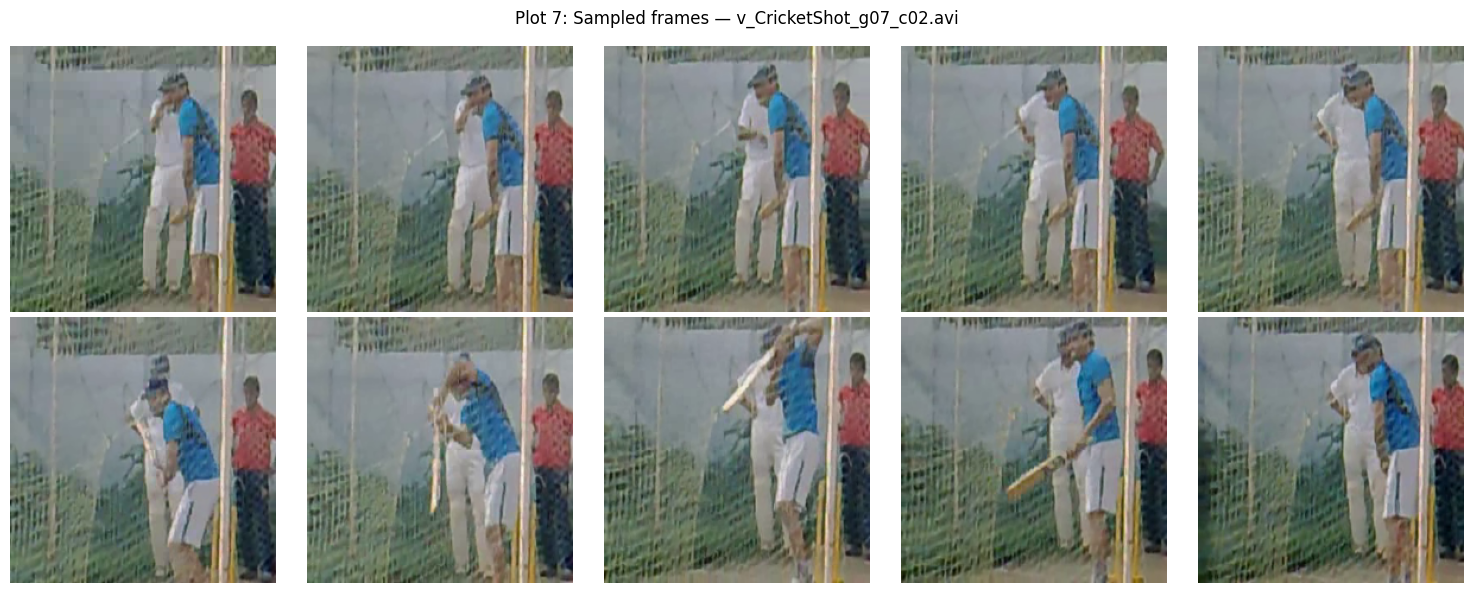

Inference: the CNN (MobileNetV2) captures spatial appearance — objects, pose,
scene context — within each individual frame, while the LSTM/GRU models how that
appearance changes across the 10 sampled frames, capturing motion/temporal dynamics
that a single frame cannot represent.


In [46]:
# Plot 7: representative sampled frames from one video
if len(video_paths) > 0:
    frames = sample_frames(video_paths[0])
    if frames is not None:
        fig, axes = plt.subplots(2, 5, figsize=(15, 6))
        for ax, fr in zip(axes.flat, frames):
            ax.imshow(fr)
            ax.axis("off")
        fig.suptitle(f"Plot 7: Sampled frames — {os.path.basename(video_paths[0])}")
        plt.tight_layout()
        plt.show()


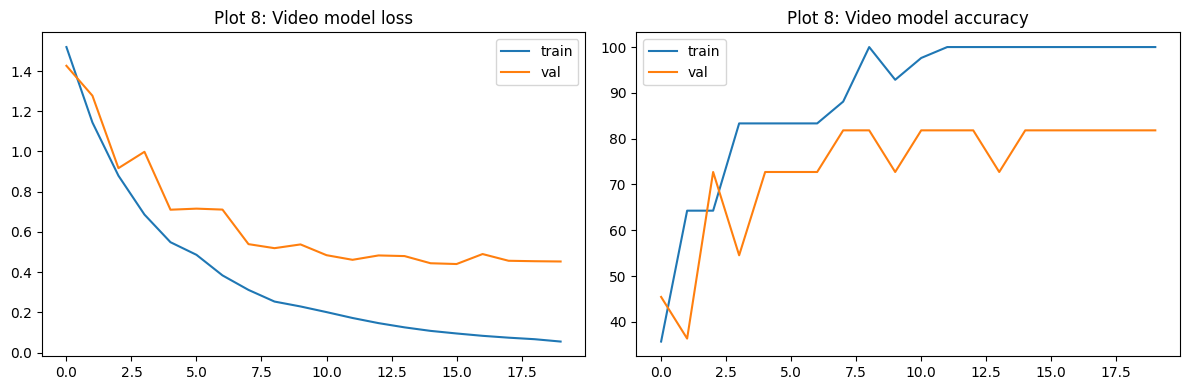

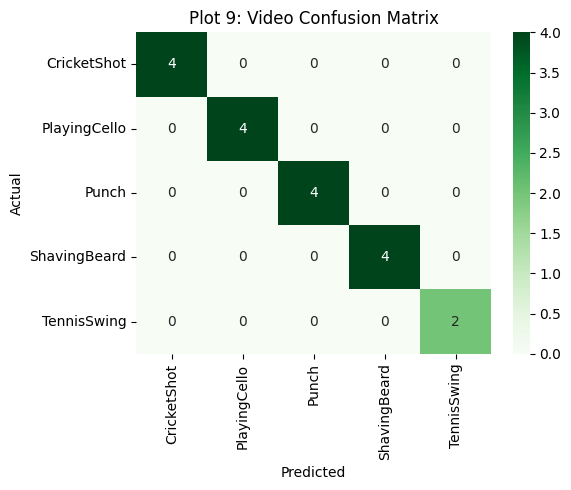

In [47]:
# Plot 8: video training/validation curves (only if the video model was trained above)
if len(video_paths) > 0 and len(X_vid_feats) >= 6:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(vid_history.history["loss"], label="train")
    axes[0].plot(vid_history.history["val_loss"], label="val")
    axes[0].set_title("Plot 8: Video model loss"); axes[0].legend()
    axes[1].plot(np.array(vid_history.history["accuracy"]) * 100, label="train")
    axes[1].plot(np.array(vid_history.history["val_accuracy"]) * 100, label="val")
    axes[1].set_title("Plot 8: Video model accuracy"); axes[1].legend()
    plt.tight_layout(); plt.show()

    # Plot 9: video confusion matrix
    cm_vid = confusion_matrix(yv_te, y_vid_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_vid, annot=True, fmt="d", cmap="Greens",
                xticklabels=VIDEO_CLASSES, yticklabels=VIDEO_CLASSES)
    plt.title("Plot 9: Video Confusion Matrix")
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.tight_layout(); plt.show()

In [54]:
VOCAB_SIZE = 10          # digits 0-9
SEQ_LEN = 4
N_SAMPLES = 20000
START_TOKEN = VOCAB_SIZE      # index 10
END_TOKEN = VOCAB_SIZE + 1    # index 11 (reserved in vocab, unused as a target here since
                               # output length is fixed and known in advance)
FULL_VOCAB = VOCAB_SIZE + 2

def make_reversal_dataset(n_samples, seq_len, vocab_size, seed=SEED):
    rng = np.random.default_rng(seed)
    X = rng.integers(0, vocab_size, size=(n_samples, seq_len))
    Y = X[:, ::-1]
    return X, Y

X_seq, Y_seq = make_reversal_dataset(N_SAMPLES, SEQ_LEN, VOCAB_SIZE)

# Teacher forcing: decoder input and target must be the SAME length (SEQ_LEN).
# decoder_input  (t=0..3) = [START, y1, y2, y3]   -> what the decoder sees at each step
# decoder_target (t=0..3) = [y1,    y2, y3, y4]   -> what it should predict at each step
decoder_input = np.concatenate([np.full((N_SAMPLES, 1), START_TOKEN), Y_seq[:, :-1]], axis=1)
decoder_target = Y_seq

Xs_tr, Xs_te, Ds_tr, Ds_te, Yt_tr, Yt_te = train_test_split(
    X_seq, decoder_input, decoder_target, test_size=0.1, random_state=SEED)

print("Example:", X_seq[0], "->", Y_seq[0])

Example: [0 7 6 4] -> [4 6 7 0]


In [50]:
EMBED_DIM = 32
LATENT_DIM = 64

# Encoder
enc_inputs = Input(shape=(SEQ_LEN,), name="encoder_input")
enc_emb = layers.Embedding(FULL_VOCAB, EMBED_DIM)(enc_inputs)
_, state_h, state_c = layers.LSTM(LATENT_DIM, return_state=True)(enc_emb)
encoder_states = [state_h, state_c]

# Decoder
dec_inputs = Input(shape=(SEQ_LEN,), name="decoder_input")
dec_emb_layer = layers.Embedding(FULL_VOCAB, EMBED_DIM)
dec_emb = dec_emb_layer(dec_inputs)
dec_lstm = layers.LSTM(LATENT_DIM, return_sequences=True, return_state=True)
dec_outputs, _, _ = dec_lstm(dec_emb, initial_state=encoder_states)
dec_dense = layers.Dense(FULL_VOCAB, activation="softmax")
dec_outputs = dec_dense(dec_outputs)

seq2seq_model = models.Model([enc_inputs, dec_inputs], dec_outputs)
seq2seq_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
seq2seq_model.summary()

seq2seq_history = seq2seq_model.fit(
    [Xs_tr, Ds_tr], Yt_tr[..., np.newaxis],
    validation_split=0.1, epochs=20, batch_size=64, verbose=1)

Model: "functional_23"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_4         │ (None, 4, 32)     │        384 │ encoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_5         │ (None, 4, 32)     │        384 │ decoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_11 (LSTM)      │ [(None, 64),      │     24,832 │ embedding_4[0][0] │
│                     │ (None, 64),       │            │                   │
│                     │ (None, 64)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_12 (LSTM)      │ [(None, 4, 64),   │     24,832 │ embedding_5[0][0… │
│                     │ (None, 64),       │            │ lstm_11[0][1],    │
│                     │ (None, 64)]       │            │ lstm_11[0][2]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_36 (Dense)    │ (None, 4, 12)     │        780 │ lstm_12[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 51,212 (200.05 KB)

 Trainable params: 51,212 (200.05 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
254/254 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.5790 - loss: 1.2500 - val_accuracy: 0.9842 - val_loss: 0.2258
Epoch 2/20
254/254 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9976 - loss: 0.0966 - val_accuracy: 0.9992 - val_loss: 0.0461
Epoch 3/20
254/254 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9999 - loss: 0.0286 - val_accuracy: 0.9999 - val_loss: 0.0199
Epoch 4/20
254/254 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 1.0000 - loss: 0.0138 - val_accuracy: 1.0000 - val_loss: 0.0107
Epoch 5/20
254/254 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 1.0000 - loss: 0.0081 - val_accuracy: 1.0000 - val_loss: 0.0066
Epoch 6/20
254/254 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 1.0000 - loss: 0.0053 - val_accuracy: 1.0000 - val_loss: 0.0045
Epoch 7/20
254/254 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 1.0000 - loss: 0.0037 - val_accuracy: 1.0000 - val_loss: 0.0033
Epoch 8/20
254/254 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 1.0000 - loss: 0.0027 - val_accuracy:

In [51]:
# Inference-time encoder/decoder for autoregressive decoding
encoder_model = models.Model(enc_inputs, encoder_states)

dec_state_h_in = Input(shape=(LATENT_DIM,))
dec_state_c_in = Input(shape=(LATENT_DIM,))
dec_single_input = Input(shape=(1,))
dec_single_emb = dec_emb_layer(dec_single_input)
dec_single_out, h2, c2 = dec_lstm(dec_single_emb, initial_state=[dec_state_h_in, dec_state_c_in])
dec_single_out = dec_dense(dec_single_out)
decoder_model = models.Model([dec_single_input, dec_state_h_in, dec_state_c_in],
                              [dec_single_out, h2, c2])

def decode_sequence(input_seq):
    h, c = encoder_model.predict(input_seq[np.newaxis, :], verbose=0)
    target = np.array([[START_TOKEN]])
    output = []
    for _ in range(SEQ_LEN):
        pred, h, c = decoder_model.predict([target, h, c], verbose=0)
        tok = np.argmax(pred[0, 0])
        output.append(tok)
        target = np.array([[tok]])
    return output

token_correct, token_total, seq_correct = 0, 0, 0
sample_rows = []
for i in range(len(Xs_te)):
    pred = decode_sequence(Xs_te[i])
    true = Y_seq_te_true = list(Xs_te[i][::-1])
    token_correct += sum(p == t for p, t in zip(pred, true))
    token_total += SEQ_LEN
    seq_correct += int(pred == true)
    if i < 5:
        sample_rows.append((list(Xs_te[i]), pred))

token_accuracy = token_correct / token_total
sequence_accuracy = seq_correct / len(Xs_te)

print(f"Token accuracy    : {token_accuracy:.4f}")
print(f"Sequence accuracy : {sequence_accuracy:.4f}")
print(f"Final training loss   : {seq2seq_history.history['loss'][-1]:.4f}")
print(f"Final validation loss : {seq2seq_history.history['val_loss'][-1]:.4f}")

print("\nSample Input -> Predicted Output")
for inp, pred in sample_rows:
    print(f"{inp} -> {pred}")

print("""\nInference: sequence accuracy is typically much lower than token accuracy
because a sequence only counts as correct if every single token in it is correct — one
wrong token anywhere in the sequence fails the whole example, even if the remaining
tokens are all correct, so errors compound multiplicatively across positions.""")

Token accuracy    : 1.0000
Sequence accuracy : 1.0000
Final training loss   : 0.0003
Final validation loss : 0.0003

Sample Input -> Predicted Output
[np.int64(6), np.int64(0), np.int64(2), np.int64(4)] -> [np.int64(4), np.int64(2), np.int64(0), np.int64(6)]
[np.int64(2), np.int64(7), np.int64(1), np.int64(3)] -> [np.int64(3), np.int64(1), np.int64(7), np.int64(2)]
[np.int64(1), np.int64(9), np.int64(2), np.int64(6)] -> [np.int64(6), np.int64(2), np.int64(9), np.int64(1)]
[np.int64(5), np.int64(0), np.int64(1), np.int64(6)] -> [np.int64(6), np.int64(1), np.int64(0), np.int64(5)]
[np.int64(4), np.int64(5), np.int64(2), np.int64(5)] -> [np.int64(5), np.int64(2), np.int64(5), np.int64(4)]

Inference: sequence accuracy is typically much lower than token accuracy
because a sequence only counts as correct if every single token in it is correct — one
wrong token anywhere in the sequence fails the whole example, even if the remaining
tokens are all correct, so errors compound multiplicatively 

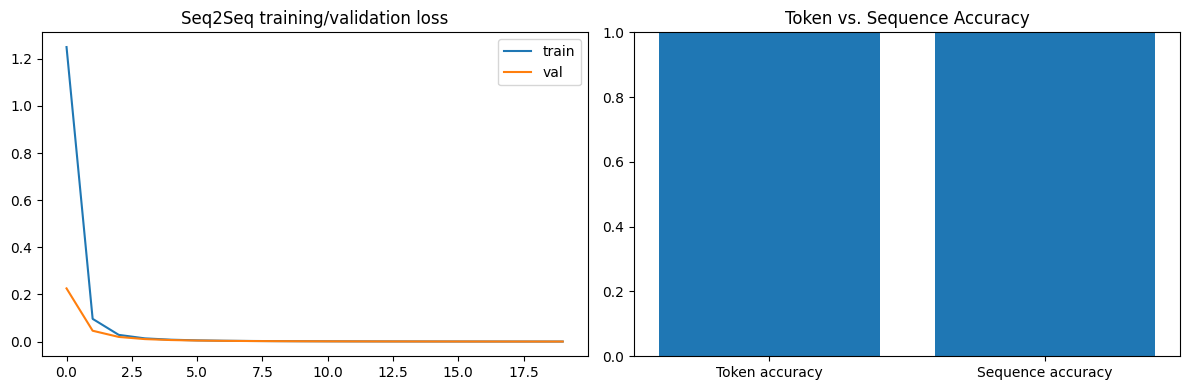

In [52]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(seq2seq_history.history["loss"], label="train")
ax[0].plot(seq2seq_history.history["val_loss"], label="val")
ax[0].set_title("Seq2Seq training/validation loss"); ax[0].legend()
ax[1].bar(["Token accuracy", "Sequence accuracy"], [token_accuracy, sequence_accuracy])
ax[1].set_ylim(0, 1)
ax[1].set_title("Token vs. Sequence Accuracy")
plt.tight_layout(); plt.show()

In [53]:
consolidated_rows = []
for rnn_type in ["RNN", "LSTM", "GRU"]:
    r = eval_results[rnn_type]
    consolidated_rows.append({
        "Model": rnn_type, "Accuracy": round(r["accuracy"], 2),
        "Precision": round(r["precision"], 2), "Recall": round(r["recall"], 2),
        "F1": round(r["f1"], 2), "Parameters": results[rnn_type]["params"],
    })
if len(video_paths) > 0 and len(X_vid_feats) >= 6:
    vid_acc = accuracy_score(yv_te, y_vid_pred) * 100
    vid_prec = precision_score(yv_te, y_vid_pred, average="macro", zero_division=0) * 100
    vid_rec = recall_score(yv_te, y_vid_pred, average="macro", zero_division=0) * 100
    vid_f1 = f1_score(yv_te, y_vid_pred, average="macro", zero_division=0) * 100
    consolidated_rows.append({
        "Model": "CNN-LSTM (video)", "Accuracy": round(vid_acc, 2),
        "Precision": round(vid_prec, 2), "Recall": round(vid_rec, 2),
        "F1": round(vid_f1, 2), "Parameters": video_model.count_params(),
    })

consolidated_df = pd.DataFrame(consolidated_rows)
print("Sequence-classification models:")
display(consolidated_df)

seq2seq_table = pd.DataFrame({
    "Metric": ["Token Accuracy", "Sequence Accuracy", "Training Loss", "Validation Loss"],
    "Value": [round(token_accuracy, 4), round(sequence_accuracy, 4),
              round(seq2seq_history.history['loss'][-1], 4),
              round(seq2seq_history.history['val_loss'][-1], 4)]
})
print("\nSequence-to-sequence task:")
display(seq2seq_table)

Sequence-classification models:


,Model,Accuracy,Precision,Recall,F1,Parameters
0,RNN,82.50,82.31,82.50,82.25,1974
1,LSTM,93.06,93.18,93.06,92.96,6006
2,GRU,93.06,93.03,93.06,93.00,4758
3,CNN-LSTM (video),100.00,100.00,100.00,100.00,168677



Sequence-to-sequence task:


,Metric,Value
0,Token Accuracy,1.0000
1,Sequence Accuracy,1.0000
2,Training Loss,0.0003
3,Validation Loss,0.0003


In [55]:
unit_sweep_rows = []
# include the already-trained 32-unit models so the table is complete
for rnn_type in ["RNN", "LSTM", "GRU"]:
    r = eval_results[rnn_type]
    unit_sweep_rows.append({"Model": rnn_type, "Units": 32, "Accuracy (%)": round(r["accuracy"], 2),
                             "F1 (%)": round(r["f1"], 2), "Parameters": results[rnn_type]["params"],
                             "Training Time (s)": round(results[rnn_type]["train_time"], 2)})

unit_sweep_models = {}
for units in [16, 64]:
    for rnn_type in ["RNN", "LSTM", "GRU"]:
        model = build_model(rnn_type, units=units)
        history, train_time = train_and_time(model, X_train_n, y_train, X_val_n, y_val,
                                              epochs=EPOCHS, verbose=0)
        y_pred = np.argmax(model.predict(X_test_n, verbose=0), axis=1)
        acc = accuracy_score(y_test, y_pred) * 100
        f1 = f1_score(y_test, y_pred, average="macro", zero_division=0) * 100
        unit_sweep_models[(rnn_type, units)] = model
        unit_sweep_rows.append({"Model": rnn_type, "Units": units, "Accuracy (%)": round(acc, 2),
                                 "F1 (%)": round(f1, 2), "Parameters": model.count_params(),
                                 "Training Time (s)": round(train_time, 2)})
        print(f"{rnn_type} ({units} units): Acc={acc:.2f}%  F1={f1:.2f}%  "
              f"Params={model.count_params()}  Time={train_time:.2f}s")

unit_sweep_df = pd.DataFrame(unit_sweep_rows).sort_values(["Model", "Units"]).reset_index(drop=True)
display(unit_sweep_df)

print("""Inference: increasing units generally raises parameter count and training time
roughly linearly-to-quadratically (recurrent weight matrices scale with units^2), while
accuracy/F1 gains typically diminish beyond a point since the UCF/HAR task's temporal
patterns are simple enough that 32 units already captures most of the useful signal.""")

RNN (16 units): Acc=69.44%  F1=69.69%  Params=790  Time=39.85s
LSTM (16 units): Acc=89.72%  F1=89.69%  Params=2038  Time=19.34s
GRU (16 units): Acc=95.28%  F1=95.23%  Params=1670  Time=36.73s
RNN (64 units): Acc=85.56%  F1=85.52%  Params=5878  Time=42.40s
LSTM (64 units): Acc=59.44%  F1=53.71%  Params=20086  Time=20.09s
GRU (64 units): Acc=95.28%  F1=95.25%  Params=15542  Time=20.99s


,Model,Units,Accuracy (%),F1 (%),Parameters,Training Time (s)
0,GRU,16,95.28,95.23,1670,36.73
1,GRU,32,93.06,93.00,4758,20.27
2,GRU,64,95.28,95.25,15542,20.99
3,LSTM,16,89.72,89.69,2038,19.34
4,LSTM,32,93.06,92.96,6006,26.94
5,LSTM,64,59.44,53.71,20086,20.09
6,RNN,16,69.44,69.69,790,39.85
7,RNN,32,82.50,82.25,1974,28.64
8,RNN,64,85.56,85.52,5878,42.40


Inference: increasing units generally raises parameter count and training time
roughly linearly-to-quadratically (recurrent weight matrices scale with units^2), while
accuracy/F1 gains typically diminish beyond a point since the UCF/HAR task's temporal
patterns are simple enough that 32 units already captures most of the useful signal.


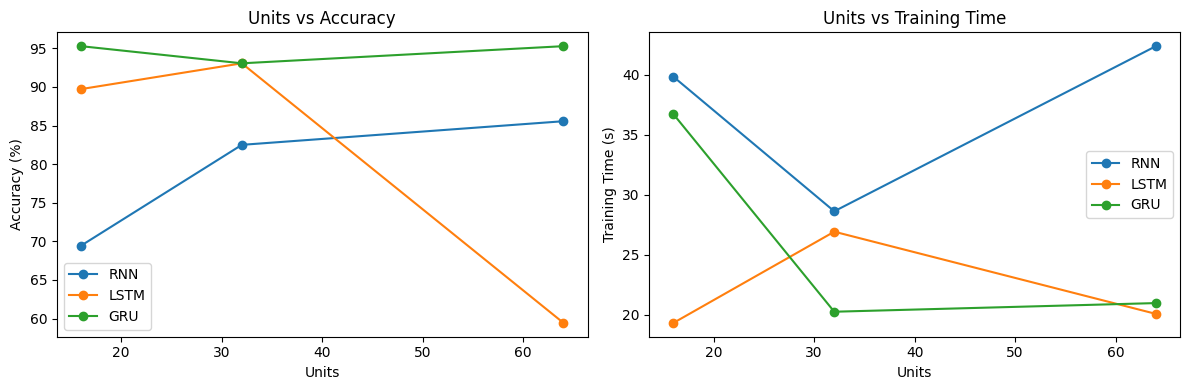

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for rnn_type in ["RNN", "LSTM", "GRU"]:
    sub = unit_sweep_df[unit_sweep_df["Model"] == rnn_type].sort_values("Units")
    axes[0].plot(sub["Units"], sub["Accuracy (%)"], marker="o", label=rnn_type)
    axes[1].plot(sub["Units"], sub["Training Time (s)"], marker="o", label=rnn_type)
axes[0].set_xlabel("Units"); axes[0].set_ylabel("Accuracy (%)"); axes[0].set_title("Units vs Accuracy"); axes[0].legend()
axes[1].set_xlabel("Units"); axes[1].set_ylabel("Training Time (s)"); axes[1].set_title("Units vs Training Time"); axes[1].legend()
plt.tight_layout(); plt.show()

In [57]:
gru_vs_lstm = unit_sweep_df[unit_sweep_df["Model"].isin(["LSTM", "GRU"])].pivot(
    index="Units", columns="Model", values=["Accuracy (%)", "F1 (%)", "Parameters", "Training Time (s)"])
display(gru_vs_lstm)

print("""Inference: at matched unit counts, GRU consistently uses fewer parameters than
LSTM (2 gates vs 3, no separate cell state) and trains faster, while typically reaching
accuracy/F1 close to LSTM's — the classic GRU trade-off of comparable predictive power
at lower computational cost.""")

Accuracy (%)        F1 (%)        Parameters          Training Time (s)  \
Model          GRU   LSTM    GRU   LSTM        GRU     LSTM               GRU   
Units                                                                           
16           95.28  89.72  95.23  89.69     1670.0   2038.0             36.73   
32           93.06  93.06  93.00  92.96     4758.0   6006.0             20.27   
64           95.28  59.44  95.25  53.71    15542.0  20086.0             20.99   

              
Model   LSTM  
Units         
16     19.34  
32     26.94  
64     20.09

Inference: at matched unit counts, GRU consistently uses fewer parameters than
LSTM (2 gates vs 3, no separate cell state) and trains faster, while typically reaching
accuracy/F1 close to LSTM's — the classic GRU trade-off of comparable predictive power
at lower computational cost.


In [58]:
def build_stacked_model(rnn_type, seq_len=128, n_features=9, units=32, n_classes=6):
    RecurrentLayer = {"RNN": layers.SimpleRNN, "LSTM": layers.LSTM, "GRU": layers.GRU}[rnn_type]
    model = models.Sequential([
        Input(shape=(seq_len, n_features)),
        RecurrentLayer(units, return_sequences=True),
        layers.Dropout(0.2),
        RecurrentLayer(units),
        layers.Dropout(0.2),
        layers.Dense(16, activation="relu"),
        layers.Dense(n_classes, activation="softmax"),
    ], name=f"{rnn_type}_stacked")
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

stacked_rows = []
for rnn_type in ["RNN", "LSTM", "GRU"]:
    model = build_stacked_model(rnn_type)
    history, train_time = train_and_time(model, X_train_n, y_train, X_val_n, y_val,
                                          epochs=EPOCHS, verbose=0)
    y_pred = np.argmax(model.predict(X_test_n, verbose=0), axis=1)
    acc = accuracy_score(y_test, y_pred) * 100
    f1 = f1_score(y_test, y_pred, average="macro", zero_division=0) * 100
    stacked_rows.append({"Model": rnn_type, "Layers": 2, "Accuracy (%)": round(acc, 2),
                          "F1 (%)": round(f1, 2), "Parameters": model.count_params(),
                          "Training Time (s)": round(train_time, 2)})
    single = eval_results[rnn_type]
    stacked_rows.append({"Model": rnn_type, "Layers": 1, "Accuracy (%)": round(single["accuracy"], 2),
                          "F1 (%)": round(single["f1"], 2), "Parameters": results[rnn_type]["params"],
                          "Training Time (s)": round(results[rnn_type]["train_time"], 2)})

stacked_df = pd.DataFrame(stacked_rows).sort_values(["Model", "Layers"]).reset_index(drop=True)
display(stacked_df)

,Model,Layers,Accuracy (%),F1 (%),Parameters,Training Time (s)
0,GRU,1,93.06,93.00,4758,20.27
1,GRU,2,95.00,94.98,11094,28.80
2,LSTM,1,93.06,92.96,6006,26.94
3,LSTM,2,94.72,94.65,14326,29.03
4,RNN,1,82.50,82.25,1974,28.64
5,RNN,2,81.67,81.49,4054,40.49


In [59]:
bilstm_model = models.Sequential([
    Input(shape=(128, 9)),
    layers.Bidirectional(layers.LSTM(32)),
    layers.Dropout(0.2),
    layers.Dense(16, activation="relu"),
    layers.Dense(6, activation="softmax"),
], name="BiLSTM_classifier")
bilstm_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
                      loss="sparse_categorical_crossentropy", metrics=["accuracy"])

bilstm_history, bilstm_time = train_and_time(bilstm_model, X_train_n, y_train, X_val_n, y_val,
                                              epochs=EPOCHS, verbose=0)
y_pred = np.argmax(bilstm_model.predict(X_test_n, verbose=0), axis=1)
bilstm_acc = accuracy_score(y_test, y_pred) * 100
bilstm_f1 = f1_score(y_test, y_pred, average="macro", zero_division=0) * 100

bidir_df = pd.DataFrame([
    {"Model": "LSTM (unidirectional)", "Accuracy (%)": round(eval_results["LSTM"]["accuracy"], 2),
     "F1 (%)": round(eval_results["LSTM"]["f1"], 2), "Parameters": results["LSTM"]["params"],
     "Training Time (s)": round(results["LSTM"]["train_time"], 2)},
    {"Model": "LSTM (bidirectional)", "Accuracy (%)": round(bilstm_acc, 2),
     "F1 (%)": round(bilstm_f1, 2), "Parameters": bilstm_model.count_params(),
     "Training Time (s)": round(bilstm_time, 2)},
])
display(bidir_df)


,Model,Accuracy (%),F1 (%),Parameters,Training Time (s)
0,LSTM (unidirectional),93.06,92.96,6006,26.94
1,LSTM (bidirectional),93.61,93.54,11894,30.42


Model,GRU,LSTM,RNN
Sequence Length,,,
32,9.15,8.10,10.86
64,9.56,9.18,11.73
128,11.46,11.03,14.51


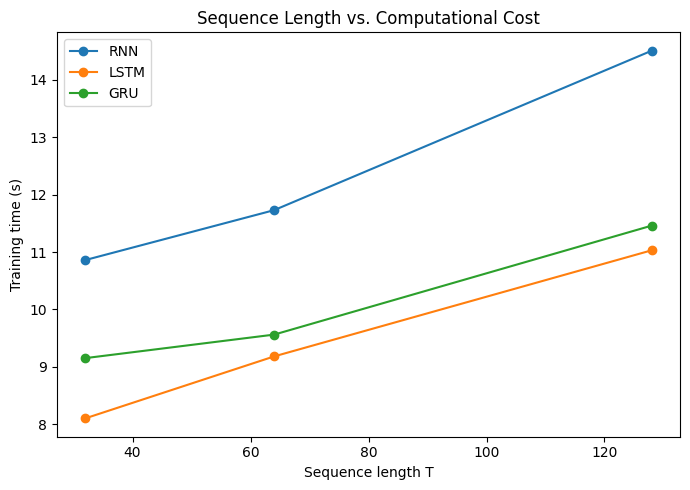

In [60]:
seqlen_time_rows = []
for T in seq_lengths:
    Xtr_T = truncate_seq(X_train_n, T)
    Xv_T = truncate_seq(X_val_n, T)
    for rnn_type in ["RNN", "LSTM", "GRU"]:
        model = build_model(rnn_type, seq_len=T)
        _, t = train_and_time(model, Xtr_T, y_train, Xv_T, y_val, epochs=15, verbose=0)
        seqlen_time_rows.append({"Sequence Length": T, "Model": rnn_type,
                                  "Training Time (s)": round(t, 2),
                                  "Parameters": model.count_params()})

seqlen_time_df = pd.DataFrame(seqlen_time_rows)
pivoted = seqlen_time_df.pivot(index="Sequence Length", columns="Model", values="Training Time (s)")
display(pivoted)

fig, ax = plt.subplots(figsize=(7, 5))
for rnn_type in ["RNN", "LSTM", "GRU"]:
    sub = seqlen_time_df[seqlen_time_df["Model"] == rnn_type]
    ax.plot(sub["Sequence Length"], sub["Training Time (s)"], marker="o", label=rnn_type)
ax.set_xlabel("Sequence length T"); ax.set_ylabel("Training time (s)")
ax.set_title("Sequence Length vs. Computational Cost")
ax.legend(); plt.tight_layout(); plt.show()


In [61]:
if len(video_paths) > 0 and len(X_vid_feats) >= 6:
    video_recurrent_comparison = []
    for rnn_type in ["LSTM", "GRU"]:
        m = build_video_model(rnn_type)
        start = time.time()
        h = m.fit(Xv_tr, yv_tr, validation_data=(Xv_val, yv_val), epochs=20, batch_size=4, verbose=0)
        t = time.time() - start
        y_pred = np.argmax(m.predict(Xv_te, verbose=0), axis=1)
        acc = accuracy_score(yv_te, y_pred) * 100
        f1 = f1_score(yv_te, y_pred, average="macro", zero_division=0) * 100
        video_recurrent_comparison.append({"Model": rnn_type, "Accuracy (%)": round(acc, 2),
                                            "F1 (%)": round(f1, 2), "Parameters": m.count_params(),
                                            "Training Time (s)": round(t, 2)})
    display(pd.DataFrame(video_recurrent_comparison))

,Model,Accuracy (%),F1 (%),Parameters,Training Time (s)
0,LSTM,94.44,94.92,168677,5.19
1,GRU,100.00,100.00,126757,5.44


Inference: since both models see identical CNN-extracted spatial features,
any accuracy/F1 difference here is attributable purely to the recurrent layer's ability
to model temporal dynamics across the 10 sampled frames, not to feature quality. GRU
should train faster and use fewer parameters than LSTM; whether it also matches or beats
LSTM's accuracy on this small video subset should be read off the table above.


In [62]:
INPUT_LEN = 4
OUTPUT_LEN = 8
N_SAMPLES_2 = 20000
START_TOKEN_2 = VOCAB_SIZE  # reuse the same digit vocabulary (0-9) + START token

def make_repeat_dataset(n_samples, input_len, vocab_size, seed=SEED):
    rng = np.random.default_rng(seed)
    X = rng.integers(0, vocab_size, size=(n_samples, input_len))
    Y = np.concatenate([X, X], axis=1)  # output = input repeated twice -> length 2*input_len
    return X, Y

X_in2, Y_out2 = make_repeat_dataset(N_SAMPLES_2, INPUT_LEN, VOCAB_SIZE)
decoder_input2 = np.concatenate([np.full((N_SAMPLES_2, 1), START_TOKEN_2), Y_out2[:, :-1]], axis=1)
decoder_target2 = Y_out2

Xi_tr, Xi_te, Di_tr, Di_te, Yo_tr, Yo_te = train_test_split(
    X_in2, decoder_input2, decoder_target2, test_size=0.1, random_state=SEED)

print("Example:", X_in2[0], "->", Y_out2[0])
print(f"Input length: {INPUT_LEN}, Output length: {OUTPUT_LEN}")

Example: [0 7 6 4] -> [0 7 6 4 0 7 6 4]
Input length: 4, Output length: 8


In [63]:
EMBED_DIM_2, LATENT_DIM_2 = 32, 64
FULL_VOCAB_2 = VOCAB_SIZE + 1  # digits + START (no END token needed, fixed-length decode)

enc_inputs2 = Input(shape=(INPUT_LEN,), name="encoder_input2")
enc_emb2 = layers.Embedding(FULL_VOCAB_2, EMBED_DIM_2)(enc_inputs2)
_, sh2, sc2 = layers.LSTM(LATENT_DIM_2, return_state=True)(enc_emb2)
encoder_states2 = [sh2, sc2]

dec_inputs2 = Input(shape=(OUTPUT_LEN,), name="decoder_input2")
dec_emb_layer2 = layers.Embedding(FULL_VOCAB_2, EMBED_DIM_2)
dec_emb2 = dec_emb_layer2(dec_inputs2)
dec_lstm2 = layers.LSTM(LATENT_DIM_2, return_sequences=True, return_state=True)
dec_out2, _, _ = dec_lstm2(dec_emb2, initial_state=encoder_states2)
dec_dense2 = layers.Dense(FULL_VOCAB_2, activation="softmax")
dec_out2 = dec_dense2(dec_out2)

seq2seq_model2 = models.Model([enc_inputs2, dec_inputs2], dec_out2)
seq2seq_model2.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
seq2seq_model2.summary()

seq2seq_history2 = seq2seq_model2.fit(
    [Xi_tr, Di_tr], Yo_tr[..., np.newaxis],
    validation_split=0.1, epochs=20, batch_size=64, verbose=1)

Model: "functional_47"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input2      │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input2      │ (None, 8)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_6         │ (None, 4, 32)     │        352 │ encoder_input2[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_7         │ (None, 8, 32)     │        352 │ decoder_input2[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_22 (LSTM)      │ [(None, 64),      │     24,832 │ embedding_6[0][0] │
│                     │ (None, 64),       │            │                   │
│                     │ (None, 64)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_23 (LSTM)      │ [(None, 8, 64),   │     24,832 │ embedding_7[0][0… │
│                     │ (None, 64),       │            │ lstm_22[0][1],    │
│                     │ (None, 64)]       │            │ lstm_22[0][2]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_79 (Dense)    │ (None, 8, 11)     │        715 │ lstm_23[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 51,083 (199.54 KB)

 Trainable params: 51,083 (199.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
254/254 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.4273 - loss: 1.4924 - val_accuracy: 0.7230 - val_loss: 0.7660
Epoch 2/20
254/254 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8884 - loss: 0.4068 - val_accuracy: 0.9345 - val_loss: 0.2515
Epoch 3/20
254/254 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9639 - loss: 0.1716 - val_accuracy: 0.9698 - val_loss: 0.1341
Epoch 4/20
254/254 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9844 - loss: 0.0981 - val_accuracy: 0.9893 - val_loss: 0.0762
Epoch 5/20
254/254 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9909 - loss: 0.0686 - val_accuracy: 0.9919 - val_loss: 0.0582
Epoch 6/20
254/254 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9951 - loss: 0.0482 - val_accuracy: 0.9872 - val_loss: 0.0614
Epoch 7/20
254/254 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9974 - loss: 0.0344 - val_accuracy: 0.9957 - val_loss: 0.0373
Epoch 8/20
254/254 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9954 - loss: 0.0345 - val_accuracy: 0

In [ ]:
encoder_model2 = models.Model(enc_inputs2, encoder_states2)
dec_h_in2 = Input(shape=(LATENT_DIM_2,))
dec_c_in2 = Input(shape=(LATENT_DIM_2,))
dec_single_in2 = Input(shape=(1,))
dec_single_emb2 = dec_emb_layer2(dec_single_in2)
dec_single_out2, h3, c3 = dec_lstm2(dec_single_emb2, initial_state=[dec_h_in2, dec_c_in2])
dec_single_out2 = dec_dense2(dec_single_out2)
decoder_model2 = models.Model([dec_single_in2, dec_h_in2, dec_c_in2], [dec_single_out2, h3, c3])

def decode_sequence2(input_seq):
    h, c = encoder_model2.predict(input_seq[np.newaxis, :], verbose=0)
    target = np.array([[START_TOKEN_2]])
    output = []
    for _ in range(OUTPUT_LEN):
        pred, h, c = decoder_model2.predict([target, h, c], verbose=0)
        tok = np.argmax(pred[0, 0])
        output.append(tok)
        target = np.array([[tok]])
    return output

token_correct2, token_total2, seq_correct2 = 0, 0, 0
sample_rows2 = []
for i in range(len(Xi_te)):
    pred = decode_sequence2(Xi_te[i])
    true = list(np.concatenate([Xi_te[i], Xi_te[i]]))
    token_correct2 += sum(p == t for p, t in zip(pred, true))
    token_total2 += OUTPUT_LEN
    seq_correct2 += int(pred == true)
    if i < 5:
        sample_rows2.append((list(Xi_te[i]), pred))

print(f"Token accuracy    : {token_correct2/token_total2:.4f}")
print(f"Sequence accuracy : {seq_correct2/len(Xi_te):.4f}")
print("\nSample Input (len 4) -> Predicted Output (len 8)")
for inp, pred in sample_rows2:
    print(f"{inp} -> {pred}")
